# Part 1 — The Business Problem

## Understanding the Business Problem

The business problem is to understand which customer characteristics and service-related factors are associated with customer churn. The company wants to identify patterns among customers who leave so that these patterns can later be used to build a churn prediction model. The likely target variable is `Churn`, because it indicates whether a customer left the company.

# Part 2 — Exploring the Dataset Structure

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

## Task 2 — Expected Predictors

### Five useful predictors

1. **Contract** — Contract type is likely useful because customers with different contract lengths may have different levels of commitment and churn risk.

2. **tenure** — Tenure represents how long a customer has stayed with the company and may indicate customer loyalty.

3. **MonthlyCharges** — Higher monthly charges may be associated with greater churn because customers may be more sensitive to cost.

4. **InternetService** — Different internet service types may have different customer experiences and churn rates.

5. **PaymentMethod** — Payment method may be associated with customer behavior and billing preferences, which could relate to churn.

### Two columns expected to be useless

1. **customerID** — It is only an identifier and does not describe customer behavior or characteristics.

2. **Churn** — It is the target variable that we want to predict, so it should not be used as an input feature.

## Task 3 — Questions I Want the Data to Answer

1. Are customers with month-to-month contracts more likely to churn than customers with longer contracts?

2. Are customers with higher monthly charges or shorter tenure more likely to churn?

## Task 4 — Dataset Size and Feature Types

The dataset contains 7,043 customers and 21 columns. One column, `customerID`, is an identifier, while `Churn` is the target variable. The remaining columns describe customer demographics, services, contract information, payment information, and charges.

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

## Task 5 — Identifiers and Incorrect Data Types

The `customerID` column is an identifier rather than a useful predictive feature because it uniquely identifies each customer and does not describe customer behavior. The `TotalCharges` column is stored as an object/text data type even though it represents numerical charges, so it needs to be converted to a numeric type.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [8]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


C:\Users\Hp\AppData\Local\Temp\ipykernel_11384\3333198144.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns.tolist()


In [9]:
for col in ['gender', 'InternetService', 'Contract']:
    print("\n", col)
    print(df[col].unique())


 gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

 InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

 Contract
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str


## Task 6 — Unique Values

I investigated `gender`, `InternetService`, and `Contract`.

`gender` contains `Female` and `Male`.

`InternetService` contains `DSL`, `Fiber optic`, and `No`.

`Contract` contains `Month-to-month`, `One year`, and `Two year`.

The categories are consistent and do not show obvious spelling or formatting inconsistencies.

In [10]:
missing_count = df.isnull().sum()
missing_percentage = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

missing_table

,Missing Count,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [11]:
df[df['TotalCharges'].str.strip() == '']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [12]:
df[df['TotalCharges'].str.strip() == '']['customerID']

488     4472-LVYGI
753     3115-CZMZD
936     5709-LVOEQ
1082    4367-NUYAO
1340    1371-DWPAZ
3331    7644-OMVMY
3826    3213-VVOLG
4380    2520-SGTTA
5218    2923-ARZLG
6670    4075-WKNIU
6754    2775-SEFEE
Name: customerID, dtype: str

## Task 7 — Missing Values

I checked the dataset for missing values by calculating both the number and percentage of missing values in each column. The initial `isnull()` check shows 0 missing values in all columns. However, `TotalCharges` should be investigated separately because blank values can be stored as empty strings rather than standard missing values.

After checking the `TotalCharges` column for blank strings, these values should be converted to missing numerical values and handled appropriately before creating the final cleaned dataset. Other columns do not currently show missing-value problems requiring action.


In [37]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [38]:
print("Duplicate customer IDs:", df['customerID'].duplicated().sum())

Duplicate customer IDs: 0


## Task 8 — Duplicate Investigation

The dataset contains 22 completely duplicated rows. I also checked for duplicate customer IDs separately. Duplicate rows and duplicate customer IDs are different issues: duplicate rows mean that the same complete customer record appears more than once, while duplicate customer IDs mean that the same customer identifier appears multiple times. Therefore, both checks are necessary.

In [39]:
for col in categorical_columns:
    print("\n====================")
    print(col)
    print(df[col].value_counts(dropna=False))


customerID
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429


## Task 9 — Suspicious Values

The main suspicious values were found in `TotalCharges`. Although the column represents numerical charges, it is stored as text and contains 11 blank strings. I found this by checking the data type and then searching for rows where `TotalCharges` contained an empty string. These blank values should be treated as missing numerical values.

# Part 4 — Data Cleaning Decisions

## Task 10 — Cleaning Decisions

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `customerID` is an identifier | Remove it from modeling dataframe | `drop()` | It identifies customers but does not provide useful behavioral information |
| `TotalCharges` is stored as text | Convert it to numeric | `pd.to_numeric(errors='coerce')` | The column represents numerical charges |
| 11 blank `TotalCharges` values | Convert blanks to NaN and then handle them | `pd.to_numeric(errors='coerce')` | Blank strings cannot be used as numerical values |
| Duplicate rows | Remove duplicate rows | `drop_duplicates()` | Duplicate records should not be counted more than once because they can affect analysis results |
| Duplicate customer IDs | No action required | `duplicated().sum()` | No duplicate customer IDs were found |

In [40]:
clean_df = df.copy()

In [41]:
clean_df['TotalCharges'] = pd.to_numeric(
    clean_df['TotalCharges'],
    errors='coerce'
)

In [42]:
clean_df['TotalCharges'].isnull().sum()

np.int64(11)

In [50]:
clean_df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [52]:
df[df['TotalCharges'].str.strip() == ''][
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [55]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [56]:
df[df['TotalCharges'].isnull()][
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [57]:
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0)

In [58]:
clean_df['TotalCharges'].isnull().sum()

np.int64(0)

In [61]:
clean_df = clean_df.drop(columns=['customerID'], errors='ignore')

In [97]:
clean_df = clean_df.drop_duplicates()

In [126]:
print("Final shape:", clean_df.shape)
print("Duplicate rows:", clean_df.duplicated().sum())
print("Missing values:", clean_df.isnull().sum().sum())

Final shape: (7021, 20)
Duplicate rows: 0
Missing values: 0


In [127]:
clean_df.shape

(7021, 20)

In [128]:
print("Duplicate rows:", clean_df.duplicated().sum())
print("Missing values:")
print(clean_df.isnull().sum())
print("\nData types:")
print(clean_df.dtypes)

Duplicate rows: 0
Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      floa

## Task 11 — Cleaning Confirmation

After applying the cleaning decisions, `TotalCharges` has been converted to a numerical data type and the 11 blank values have been handled by replacing them with 0. The `customerID` identifier has been removed from the cleaned dataframe. No duplicate rows were found, and the cleaned dataframe contains no missing values.

In [129]:
clean_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Task 12 — EDA Visualizations

### Numerical Variable 1 — Tenure Distribution

The histogram shows the distribution of customer tenure. It helps identify whether customers are concentrated among newer or longer-term customers and whether the distribution is skewed.


# Part 5 — Univariate EDA

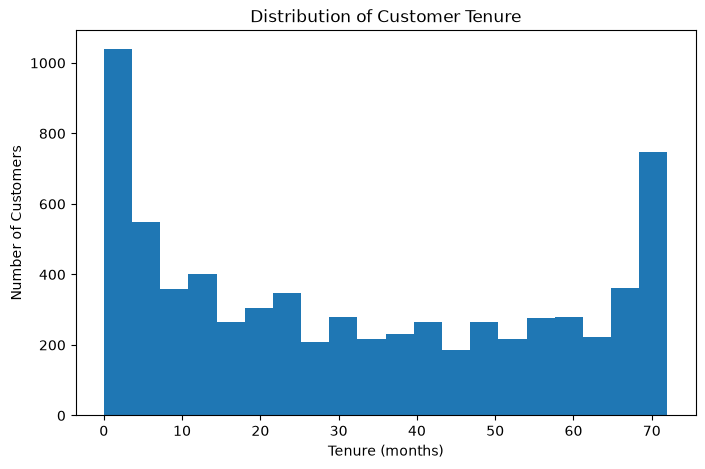

In [130]:
plt.figure(figsize=(8,5))

plt.hist(clean_df['tenure'], bins=20)

plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')

plt.show()

### Interpretation — Tenure

The tenure distribution shows how long customers have remained with the company. There are many customers with relatively short tenure, while other customers have remained for several years.

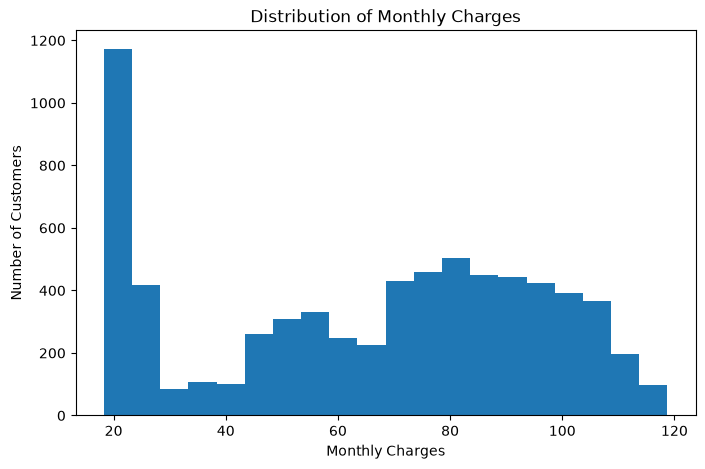

In [131]:
plt.figure(figsize=(8,5))

plt.hist(clean_df['MonthlyCharges'], bins=20)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')

plt.show()

### Interpretation — Monthly Charges

Monthly charges are spread across a wide range of prices. The distribution shows that customers pay different monthly amounts depending on the services they use.

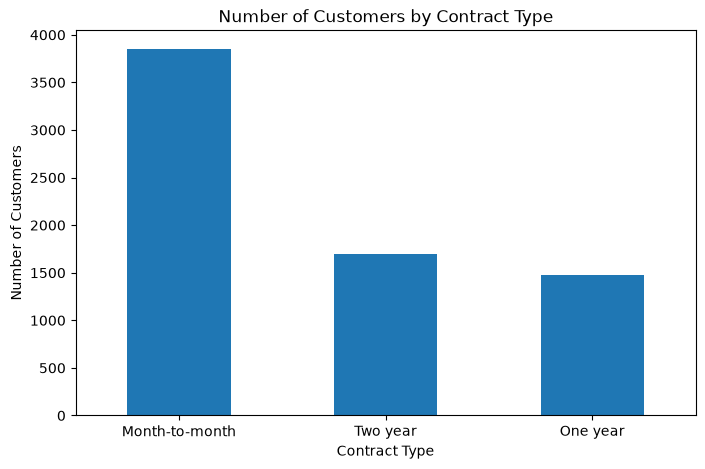

In [132]:
plt.figure(figsize=(8,5))

clean_df['Contract'].value_counts().plot(kind='bar')

plt.title('Number of Customers by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

### Interpretation — Contract

The majority of customers have month-to-month contracts, while fewer customers have one-year or two-year contracts. This is important because contract type may be related to customer churn.

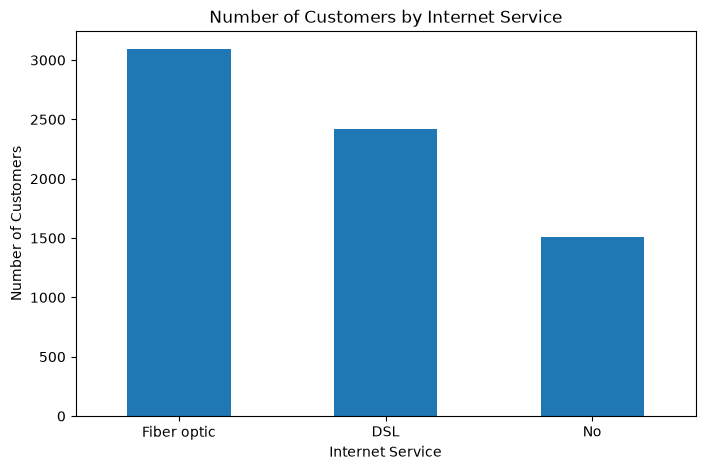

In [133]:
plt.figure(figsize=(8,5))

clean_df['InternetService'].value_counts().plot(kind='bar')

plt.title('Number of Customers by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

### Interpretation — Internet Service

Customers use DSL, fiber optic, or no internet service. Fiber optic and DSL customers make up most of the customer base, while a smaller group does not use internet service.

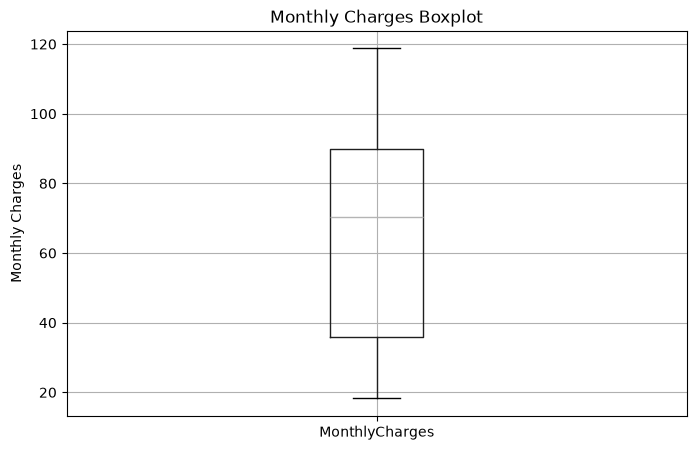

In [134]:
plt.figure(figsize=(8,5))

clean_df.boxplot(column='MonthlyCharges')

plt.title('Monthly Charges Boxplot')
plt.ylabel('Monthly Charges')

plt.show()

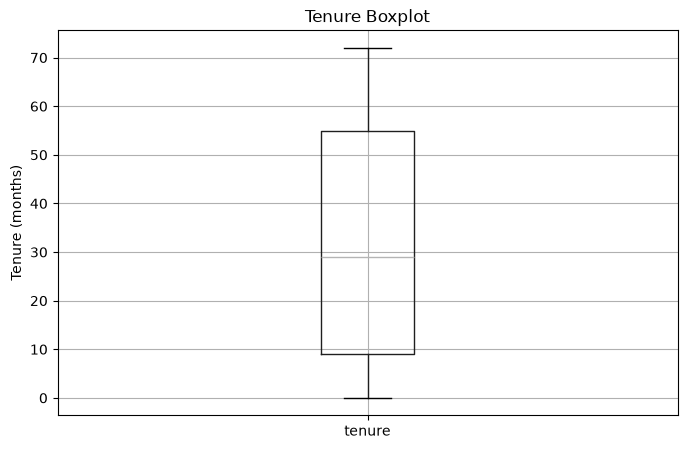

In [135]:
plt.figure(figsize=(8,5))

clean_df.boxplot(column='tenure')

plt.title('Tenure Boxplot')
plt.ylabel('Tenure (months)')

plt.show()

## Task 13 — Outliers and Skewness

The numerical variables have different distributions. MonthlyCharges contains customers with relatively high charges compared with the center of the distribution. Tenure is bounded between 0 and 72 months, so its distribution is influenced by the maximum possible customer tenure. These patterns are likely related to differences in services, contracts, and customer length of stay.

# Part 6 — Target Variable Analysis

In [136]:
churn_counts = clean_df['Churn'].value_counts()
churn_percentages = clean_df['Churn'].value_counts(normalize=True) * 100

print("Counts:")
print(churn_counts)

print("\nPercentages:")
print(churn_percentages)

Counts:
Churn
No     5164
Yes    1857
Name: count, dtype: int64

Percentages:
Churn
No     73.550776
Yes    26.449224
Name: proportion, dtype: float64


## Task 14 — Churn Distribution

There are 5,174 customers who did not churn and 1,869 customers who churned.

Therefore:

- Non-churned customers: 73.46%
- Churned customers: 26.54%

The target variable is somewhat imbalanced because the non-churn class contains substantially more customers than the churn class.

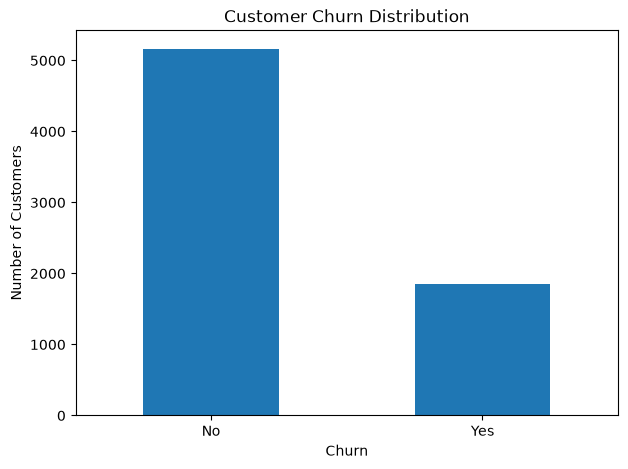

In [137]:
plt.figure(figsize=(7,5))

clean_df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.xticks(rotation=0)

plt.show()

## Task 15 — Why Class Imbalance Matters

Class imbalance matters because a model could achieve a seemingly high accuracy by mainly predicting the majority class. In this dataset, non-churned customers are much more common than churned customers, so accuracy alone may not fully represent how well the model identifies customers who actually churn.

# Part 7 — Bivariate Analysis: Features vs. Churn

In [138]:
contract_churn = pd.crosstab(
    clean_df['Contract'],
    clean_df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.357903,42.642097
One year,88.730482,11.269518
Two year,97.168142,2.831858


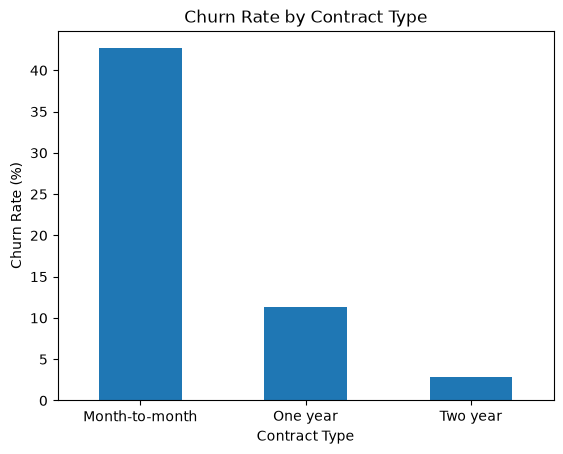

In [139]:
contract_churn['Yes'].plot(kind='bar')

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

plt.show()

### Task 16: Contract — Observation 

**Observation:** Month-to-month customers have a much higher churn rate than customers with one-year or two-year contracts.

**Evidence:** The churn rate is approximately 42.71% for month-to-month customers, 11.27% for one-year customers, and 2.83% for two-year customers.

**Possible Explanation:** Customers with longer contracts may be more committed to the company, while month-to-month customers have more flexibility to leave.

In [140]:
internet_churn = pd.crosstab(
    clean_df['InternetService'],
    clean_df['Churn'],
    normalize='index'
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.107896,18.892104
Fiber optic,58.220065,41.779935
No,92.791005,7.208995


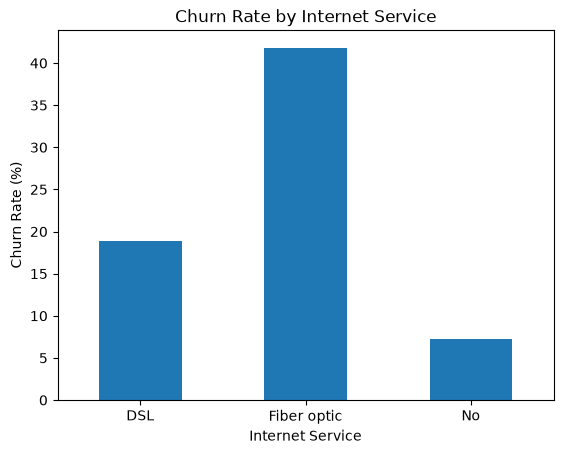

In [141]:
internet_churn['Yes'].plot(kind='bar')

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=0)

plt.show()

### InternetService — Observation 

**Observation:** Fiber optic customers have the highest churn rate among the three internet-service groups.

**Evidence:** The churn rate is approximately 41.89% for fiber optic customers, 18.96% for DSL customers, and 7.41% for customers without internet service.

**Possible Explanation:** The higher churn among fiber optic customers may be related to pricing, service expectations, competition, or other factors. The data shows an association but does not prove the exact cause.

In [142]:
clean_df.groupby('Churn')['tenure'].agg(['mean', 'median'])

,mean,median
Churn,,
No,37.640782,38.0
Yes,18.088853,10.0


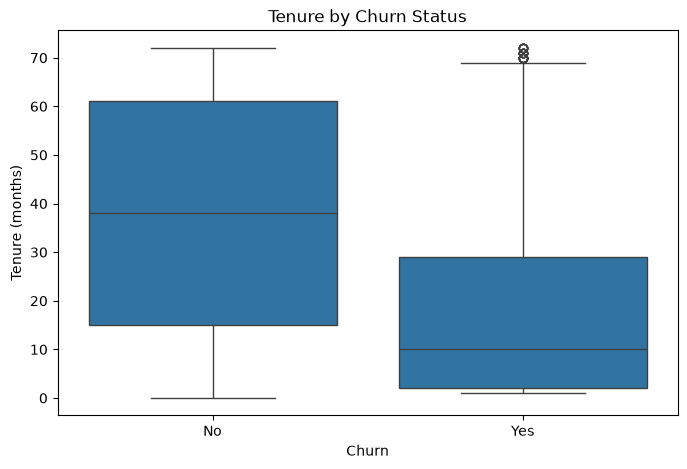

In [143]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=clean_df
)

plt.title('Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (months)')

plt.show()

### Task 17: Tenure — Observation 

**Observation:** Customers who churn generally have shorter tenure than customers who do not churn.

**Evidence:** The average tenure of non-churned customers is approximately 37.57 months, compared with approximately 17.98 months for churned customers. The median is 38 months for non-churned customers and 10 months for churned customers.

**Possible Explanation:** Newer customers may be less committed to the company and may be more likely to leave if their expectations are not met.

In [144]:
clean_df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median'])

,mean,median
Churn,,
No,61.344878,64.5
Yes,74.604308,79.7


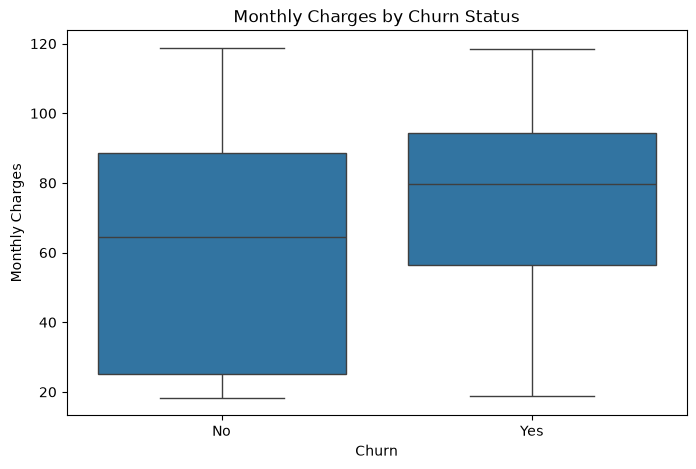

In [145]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=clean_df
)

plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

### MonthlyCharges — Observation 

**Observation:** Customers who churn tend to have higher monthly charges than customers who do not churn.

**Evidence:** The average monthly charge is approximately $74.44 for churned customers compared with approximately $61.27 for non-churned customers.

**Possible Explanation:** Higher monthly charges may be associated with more expensive service packages or higher customer costs, which could contribute to dissatisfaction or switching.

# Part 8 — Correlation & Feature Relationships

In [146]:
corr = clean_df.corr(numeric_only=True)

corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015349,0.219434,0.102243
tenure,0.015349,1.000000,0.245251,0.825595
MonthlyCharges,0.219434,0.245251,1.000000,0.650653
TotalCharges,0.102243,0.825595,0.650653,1.000000


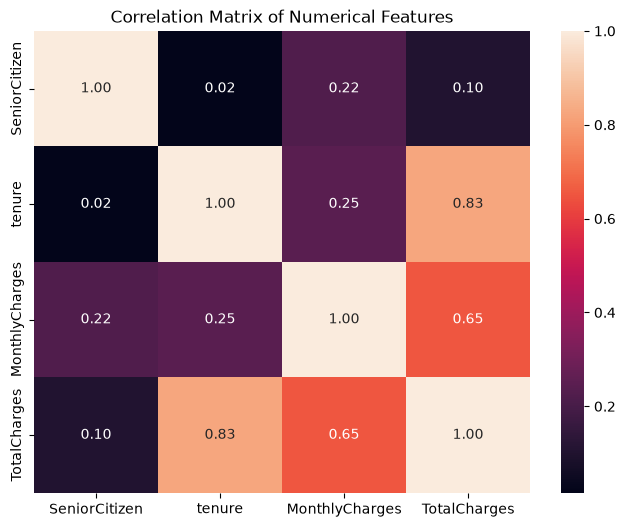

In [147]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

## Task 18 — Correlation Findings

The strongest correlation is between `tenure` and `TotalCharges`, with a correlation of approximately 0.83. `MonthlyCharges` and `TotalCharges` also have a relatively strong positive correlation of approximately 0.65. `tenure` and `MonthlyCharges` have a weaker positive correlation of approximately 0.25.

## Task 19 — Correlation Does Not Mean Causation

Correlation does not prove that one variable causes another. For example, `tenure` and `TotalCharges` are strongly correlated partly because customers who stay longer have more time to accumulate charges. Highly correlated features can also contain overlapping information, which may create redundancy in a future model.

# Part 9 — Data Leakage Awareness

## Task 20 — Possible Leakage and Identifier Columns

The `customerID` column is a clear identifier and should not be used as a predictive feature because it only identifies the customer. `Churn` is the target variable and therefore must not be included as an input feature when training the future model. `TotalCharges` should also be considered carefully because it represents accumulated charges and may contain information closely related to the customer's tenure and history.

## Task 21 — Why Leakage Is a Problem

If information that would not realistically be available at prediction time is included in the model, the model may appear much more accurate than it really is. This is called data leakage because the model receives information about the outcome or future information that it should not have access to.

# Part 10 — ML-Readiness Checklist

## Task 22 — ML-Readiness Table

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Categorical/Identifier | Identifier | Remove | Only identifies the customer |
| gender | Categorical | Feature | Keep | Customer demographic feature |
| SeniorCitizen | Numerical | Feature | Keep | Customer demographic information |
| Partner | Categorical | Feature | Keep | Describes customer household status |
| Dependents | Categorical | Feature | Keep | Describes customer household status |
| tenure | Numerical | Feature | Keep | Measures length of customer relationship |
| PhoneService | Categorical | Feature | Keep | Describes subscribed service |
| MultipleLines | Categorical | Feature | Keep | Describes phone service |
| InternetService | Categorical | Feature | Keep | Describes internet service |
| OnlineSecurity | Categorical | Feature | Keep | Describes subscribed service |
| OnlineBackup | Categorical | Feature | Keep | Describes subscribed service |
| DeviceProtection | Categorical | Feature | Keep | Describes subscribed service |
| TechSupport | Categorical | Feature | Keep | Describes subscribed service |
| StreamingTV | Categorical | Feature | Keep | Describes subscribed service |
| StreamingMovies | Categorical | Feature | Keep | Describes subscribed service |
| Contract | Categorical | Feature | Keep | Important contract characteristic |
| PaperlessBilling | Categorical | Feature | Keep | Describes billing preference |
| PaymentMethod | Categorical | Feature | Keep | Describes payment method |
| MonthlyCharges | Numerical | Feature | Keep | Numerical billing feature |
| TotalCharges | Numerical | Feature | Keep | Numerical accumulated billing feature |
| Churn | Categorical | Target | Keep | This is the variable to predict |

# Part 11 — Building the Clean Dataset

In [148]:
clean_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [149]:
clean_df.shape

(7021, 20)

In [150]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  MonthlyChar

In [151]:
print("Total missing values:", clean_df.isnull().sum().sum())
print("Total duplicate rows:", clean_df.duplicated().sum())

Total missing values: 0
Total duplicate rows: 0


## Task 23 — Create the Final Clean Dataset

In [152]:
clean_df.to_csv('clean_churn.csv', index=False)

In [153]:
print("Clean dataset saved successfully as clean_churn.csv")

Clean dataset saved successfully as clean_churn.csv


## Task: 24 Final Dataset Varification

In [154]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   str    
 17  MonthlyChar

In [155]:
print("Final shape:", clean_df.shape)
print("Total missing values:", clean_df.isnull().sum().sum())
print("Total duplicate rows:", clean_df.duplicated().sum())

Final shape: (7021, 20)
Total missing values: 0
Total duplicate rows: 0


# Part 12 — Key Findings & Final Reflection

## Task 25 — Five Key Findings

### Finding 1 — Contract Type

**Observation:** Customers with month-to-month contracts have much higher churn than customers with longer contracts.

**Evidence:** The churn rate is approximately 42.71% for month-to-month customers, compared with 11.27% for one-year customers and 2.83% for two-year customers.

**Interpretation:** Contract length is strongly associated with churn. Customers with longer contracts appear more likely to remain with the company.

---

### Finding 2 — Customer Tenure

**Observation:** Churned customers generally have shorter tenure.

**Evidence:** The average tenure is approximately 17.98 months for churned customers compared with 37.57 months for non-churned customers.

**Interpretation:** Newer customers appear more likely to churn than long-term customers.

---

### Finding 3 — Monthly Charges

**Observation:** Churned customers tend to have higher monthly charges.

**Evidence:** The average monthly charge is approximately 74.44 for churned customers compared with approximately 61.27 for non-churned customers.

**Interpretation:** Higher monthly charges are associated with higher churn in this dataset.

---

### Finding 4 — Internet Service

**Observation:** Fiber optic customers have a higher churn rate than DSL and customers without internet service.

**Evidence:** The churn rate is approximately 41.89% for fiber optic customers, 18.96% for DSL customers, and 7.41% for customers without internet service.

**Interpretation:** Internet service type appears to be an important variable associated with churn, although the data alone does not establish the reason for this relationship.

---

### Finding 5 — Target Distribution

**Observation:** Most customers do not churn.

**Evidence:** 5,174 customers do not churn, representing approximately 73.46% of the dataset, while 1,869 customers churn, representing approximately 26.54%.

**Interpretation:** The target variable is imbalanced, with non-churn customers being the majority class. This should be considered when evaluating a future classification model.

## Task: 26 Final Reflection

### 1. What was the most important data-quality issue you found?

The most important data-quality issue was that `TotalCharges` was stored as a text column instead of a numerical column. It also contained 11 blank values. I converted the column to numeric and handled the missing values before creating the final cleaned dataframe.

### 2. What was the most interesting pattern you discovered?

The most interesting pattern was the strong relationship between contract type and churn. Month-to-month customers had a much higher churn rate than customers with one-year or two-year contracts.

### 3. Which feature seems most useful for predicting churn?

Contract type appears to be one of the most useful features because the churn rates differ substantially between month-to-month, one-year, and two-year contracts. Tenure also appears highly useful because churned customers have considerably shorter tenure.

### 4. Which feature should probably not be used, and why?

`customerID` should not be used because it is simply an identifier. It does not represent a meaningful customer characteristic and could cause the model to learn meaningless patterns.

### 5. What preprocessing will be required before ML modeling?

Before ML modeling, categorical variables will need to be converted into numerical representations. Numerical variables may also need to be inspected for scale and distribution, and the target variable will need to be separated from the input features.

### 6. What would you do next if you had another 3 hours?

I would investigate additional customer segments and interactions between features, examine churn rates across combinations of contract type and payment method, and investigate why certain customer groups have particularly high churn rates. I would also prepare the cleaned dataset for the modeling stage in Lab 3.